11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 66s 6us/step


C:\Users\Ayush Raj\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training LSTM on MNIST dataset...
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 83ms/step - accuracy: 0.8197 - loss: 0.5361 - val_accuracy: 0.9407 - val_loss: 0.1889
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 92ms/step - accuracy: 0.9523 - loss: 0.1542 - val_accuracy: 0.9628 - val_loss: 0.1237
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 45s 95ms/step - accuracy: 0.9663 - loss: 0.1069 - val_accuracy: 0.9725 - val_loss: 0.0885
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - accuracy: 0.9748 - loss: 0.0825 - val_accuracy: 0.9777 - val_loss: 0.0743
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 82ms/step - accuracy: 0.9798 - loss: 0.0660 - val_accuracy: 0.9778 - val_loss: 0.0738
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9778 - loss: 0.0738
Test accuracy: 0.9778
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step

--- Postal Code Recognition (LSTM) ---


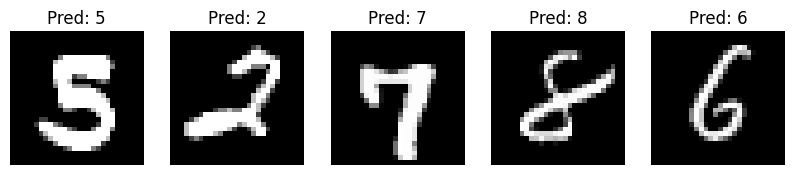

Actual digits: [5 2 7 8 6]
Decoded Postal Code: 52786


In [1]:
# Import required libraries
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# 2. Normalize pixel values (0–255 → 0–1)
x_train, x_test = x_train / 255.0, x_test / 255.0

# Shape: (samples, 28, 28) → Already suitable for LSTM (time_steps=28, features=28)

# 3. Build the LSTM model
model = models.Sequential([
    layers.LSTM(128, input_shape=(28, 28)),   # LSTM layer processes image row by row
    layers.Dense(64, activation='relu'),      # Fully connected hidden layer
    layers.Dense(10, activation='softmax')    # Output layer (digits 0–9)
])

# 4. Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Train the model
print("Training LSTM on MNIST dataset...")
model.fit(x_train, y_train, epochs=5, batch_size=128, validation_data=(x_test, y_test))

# 6. Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# ---- HANDWRITTEN POSTAL CODE DECODING ---- #
def decode_postal_code(num_digits=5):
    """Pick random digits from test set and decode them like a postal code."""
    indices = np.random.choice(len(x_test), num_digits, replace=False)
    images = x_test[indices]
    labels = y_test[indices]
    
    predictions = model.predict(images)
    predicted_digits = np.argmax(predictions, axis=1)
    
    print("\n--- Postal Code Recognition (LSTM) ---")
    plt.figure(figsize=(10, 2))
    postal_code = ""
    
    for i in range(num_digits):
        plt.subplot(1, num_digits, i+1)
        plt.imshow(images[i], cmap="gray")
        plt.axis("off")
        plt.title(f"Pred: {predicted_digits[i]}")
        postal_code += str(predicted_digits[i])
    
    plt.show()
    print(f"Actual digits: {labels}")
    print(f"Decoded Postal Code: {postal_code}")

# Decode a postal code of length 5
decode_postal_code(5)
